# Buzzhive VAE Anomaly Detector

This notebook implements a Variational Autoencoder for unsupervised anomaly detection:
1. VAE architecture design (1D CNN on MFCCs)
2. Training on "normal" (queenright) samples only
3. Anomaly detection via reconstruction error
4. Threshold calibration and evaluation


In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_curve, auc, precision_recall_curve, f1_score
from sklearn.preprocessing import LabelEncoder
import librosa

# Set device - Use CPU for VAE due to MPS AdaptiveAvgPool1d limitation
# See: https://github.com/pytorch/pytorch/issues/96056
device = torch.device('cpu')
print(f"Using device: {device}")

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

# Paths
OUTPUT_DIR = Path('../outputs')
PROCESSED_DIR = OUTPUT_DIR / 'processed'
MODEL_DIR = OUTPUT_DIR / 'models'

# Load configuration
with open(PROCESSED_DIR / 'config.json', 'r') as f:
    config_dict = json.load(f)
    
CLASS_NAMES = {int(k): v for k, v in config_dict['class_names'].items()}
print("Loaded configuration")


Using device: cpu
Loaded configuration


## 1. Data Preparation


In [2]:
# Audio configuration
class AudioConfig:
    SAMPLE_RATE = config_dict['sample_rate']
    DURATION = config_dict['duration']
    N_MELS = config_dict['n_mels']
    N_FFT = config_dict['n_fft']
    HOP_LENGTH = config_dict['hop_length']
    FMIN = config_dict['fmin']
    FMAX = config_dict['fmax']
    N_MFCC = config_dict['n_mfcc']
    PRE_EMPHASIS = config_dict['pre_emphasis']
    
    @property
    def n_samples(self):
        return int(self.SAMPLE_RATE * self.DURATION)

config = AudioConfig()

# Audio preprocessing functions
def load_audio(file_path, target_sr=22050):
    y, sr = librosa.load(file_path, sr=target_sr, mono=True)
    return y, sr

def apply_pre_emphasis(y, coef=0.97):
    return np.append(y[0], y[1:] - coef * y[:-1])

def normalize_audio(y):
    max_val = np.abs(y).max()
    if max_val > 0:
        y = y / max_val
    return y

def pad_or_truncate(y, target_length):
    if len(y) > target_length:
        start = (len(y) - target_length) // 2
        y = y[start:start + target_length]
    elif len(y) < target_length:
        pad_left = (target_length - len(y)) // 2
        pad_right = target_length - len(y) - pad_left
        y = np.pad(y, (pad_left, pad_right), mode='constant')
    return y

def preprocess_audio(file_path, config):
    y, sr = load_audio(file_path, target_sr=config.SAMPLE_RATE)
    y = apply_pre_emphasis(y, config.PRE_EMPHASIS)
    y = normalize_audio(y)
    y = pad_or_truncate(y, config.n_samples)
    return y

def extract_mfcc(y, config, include_deltas=True):
    mfccs = librosa.feature.mfcc(
        y=y, sr=config.SAMPLE_RATE, n_mfcc=config.N_MFCC,
        n_fft=config.N_FFT, hop_length=config.HOP_LENGTH
    )
    if include_deltas:
        delta = librosa.feature.delta(mfccs)
        delta2 = librosa.feature.delta(mfccs, order=2)
        mfccs = np.vstack([mfccs, delta, delta2])
    return mfccs


In [3]:
# Load data
train_df = pd.read_csv(PROCESSED_DIR / 'train_split.csv')
val_df = pd.read_csv(PROCESSED_DIR / 'val_split.csv')
test_df = pd.read_csv(PROCESSED_DIR / 'test_split.csv')

# For VAE, we train ONLY on "normal" samples
# FIXED: Using Queen_Accepted (class 3) as normal - the majority class with 1634 samples
# This gives the VAE enough data to learn a good latent representation
NORMAL_CLASS = 3  # Queen_Accepted
NORMAL_CLASS_NAME = "Queen_Accepted"

train_normal_df = train_df[train_df['queen_status'] == NORMAL_CLASS]
val_normal_df = val_df[val_df['queen_status'] == NORMAL_CLASS]

# For testing, we need both normal and anomaly samples
test_normal_df = test_df[test_df['queen_status'] == NORMAL_CLASS]
test_anomaly_df = test_df[test_df['queen_status'] != NORMAL_CLASS]

print(f"Normal class: {NORMAL_CLASS_NAME} (class {NORMAL_CLASS})")
print(f"Training data (normal only): {len(train_normal_df)}")
print(f"Validation data (normal only): {len(val_normal_df)}")
print(f"Test normal: {len(test_normal_df)}")
print(f"Test anomaly: {len(test_anomaly_df)}")


Normal class: Queen_Accepted (class 3)
Training data (normal only): 2493
Validation data (normal only): 357
Test normal: 713
Test anomaly: 709


In [4]:
# Dataset for VAE (returns MFCCs)
class MFCCDataset(Dataset):
    def __init__(self, df, config):
        self.df = df.reset_index(drop=True)
        self.config = config
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        y = preprocess_audio(row['audio_path'], self.config)
        mfcc = extract_mfcc(y, self.config)
        mfcc = torch.FloatTensor(mfcc)
        label = row['queen_status']
        return mfcc, label

# Create datasets
train_dataset = MFCCDataset(train_normal_df, config)
val_dataset = MFCCDataset(val_normal_df, config)
test_normal_dataset = MFCCDataset(test_normal_df, config)
test_anomaly_dataset = MFCCDataset(test_anomaly_df, config)

# DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Get sample to determine input shape
sample_mfcc, _ = train_dataset[0]
print(f"MFCC shape: {sample_mfcc.shape}")  # (n_mfcc*3, time_steps)


MFCC shape: torch.Size([39, 431])


## 2. VAE Architecture


In [ ]:
class ConvVAE(nn.Module):
    """
    Convolutional Variational Autoencoder for MFCC sequences.
    Uses 1D convolutions along the time axis.
    """
    
    def __init__(self, input_channels=39, seq_length=431, latent_dim=16):
        super(ConvVAE, self).__init__()
        
        self.input_channels = input_channels
        self.seq_length = seq_length
        self.latent_dim = latent_dim
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv1d(input_channels, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(8)  # Fixed size output
        )
        
        self.flatten_size = 256 * 8
        
        # Latent space
        self.fc_mu = nn.Linear(self.flatten_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_size, latent_dim)
        
        # Decoder
        self.fc_decode = nn.Linear(latent_dim, self.flatten_size)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.ConvTranspose1d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.ConvTranspose1d(64, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )
        
        # Final layer to match input dimensions
        self.final_conv = nn.Conv1d(64, input_channels, kernel_size=1)
        self.final_pool = nn.AdaptiveAvgPool1d(seq_length)
        
    def encode(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(h.size(0), 256, 8)
        h = self.decoder(h)
        h = self.final_conv(h)
        h = self.final_pool(h)
        return h
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar
    
    def reconstruction_error(self, x):
        """Compute reconstruction error for anomaly detection."""
        with torch.no_grad():
            recon, _, _ = self.forward(x)
            error = F.mse_loss(recon, x, reduction='none')
            # Average over channels and time, keep batch dimension
            error = error.mean(dim=[1, 2])
        return error


# Determine input shape from data
input_channels = sample_mfcc.shape[0]  # n_mfcc * 3 = 39
seq_length = sample_mfcc.shape[1]      # time steps

# Create model
model = ConvVAE(input_channels=input_channels, seq_length=seq_length, latent_dim=16).to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")


ConvVAE(
  (encoder): Sequential(
    (0): Conv1d(39, 64, kernel_size=(7,), stride=(2,), padding=(3,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(64, 128, kernel_size=(5,), stride=(2,), padding=(2,))
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv1d(128, 256, kernel_size=(3,), stride=(2,), padding=(1,))
    (7): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): AdaptiveAvgPool1d(output_size=8)
  )
  (fc_mu): Linear(in_features=2048, out_features=16, bias=True)
  (fc_logvar): Linear(in_features=2048, out_features=16, bias=True)
  (fc_decode): Linear(in_features=16, out_features=2048, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose1d(256, 128, kernel_size=(4,), stride=(2,), padding=(1,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True

In [6]:
# Test forward pass
with torch.no_grad():
    test_input = sample_mfcc.unsqueeze(0).to(device)
    recon, mu, logvar = model(test_input)
    print(f"Input shape: {test_input.shape}")
    print(f"Reconstruction shape: {recon.shape}")
    print(f"Latent mu shape: {mu.shape}")
    print(f"Latent logvar shape: {logvar.shape}")


Input shape: torch.Size([1, 39, 431])
Reconstruction shape: torch.Size([1, 39, 431])
Latent mu shape: torch.Size([1, 16])
Latent logvar shape: torch.Size([1, 16])


## 3. Training


In [7]:
def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    """
    VAE loss = Reconstruction loss + KL divergence
    beta controls the weight of KL term (beta-VAE)
    """
    # Reconstruction loss (MSE)
    recon_loss = F.mse_loss(recon_x, x, reduction='mean')
    
    # KL divergence
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    
    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss


def train_epoch(model, loader, optimizer, device, beta=1.0):
    model.train()
    total_loss = 0
    total_recon = 0
    total_kl = 0
    
    for batch_idx, (data, _) in enumerate(tqdm(loader, desc="Training", leave=False)):
        data = data.to(device)
        
        optimizer.zero_grad()
        recon, mu, logvar = model(data)
        loss, recon_loss, kl_loss = vae_loss(recon, data, mu, logvar, beta)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()
    
    n_batches = len(loader)
    return total_loss/n_batches, total_recon/n_batches, total_kl/n_batches


def validate(model, loader, device, beta=1.0):
    model.eval()
    total_loss = 0
    total_recon = 0
    total_kl = 0
    
    with torch.no_grad():
        for data, _ in loader:
            data = data.to(device)
            recon, mu, logvar = model(data)
            loss, recon_loss, kl_loss = vae_loss(recon, data, mu, logvar, beta)
            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()
    
    n_batches = len(loader)
    return total_loss/n_batches, total_recon/n_batches, total_kl/n_batches


In [ ]:
# Training configuration
LEARNING_RATE = 0.0005
NUM_EPOCHS = 50
PATIENCE = 10
BETA = 0.1  # KL weight (lower = focus more on reconstruction)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Training loop
history = {'train_loss': [], 'train_recon': [], 'train_kl': [],
           'val_loss': [], 'val_recon': [], 'val_kl': []}

best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

print("Starting VAE training (on normal samples only)...")
print("=" * 60)

for epoch in range(NUM_EPOCHS):
    train_loss, train_recon, train_kl = train_epoch(model, train_loader, optimizer, device, BETA)
    val_loss, val_recon, val_kl = validate(model, val_loader, device, BETA)
    
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['train_recon'].append(train_recon)
    history['train_kl'].append(train_kl)
    history['val_loss'].append(val_loss)
    history['val_recon'].append(val_recon)
    history['val_kl'].append(val_kl)
    
    print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} (Recon: {train_recon:.4f}, KL: {train_kl:.4f}) | "
          f"Val Loss: {val_loss:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        print(f"  -> New best model! Val Loss: {best_val_loss:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print("=" * 60)
print(f"Training complete. Best validation loss: {best_val_loss:.4f}")


Starting VAE training (on normal samples only)...



Training:   0%|          | 0/78 [00:00<?, ?it/s]


Training:   1%|▏         | 1/78 [00:00<00:49,  1.55it/s]


Training:   3%|▎         | 2/78 [00:01<00:46,  1.64it/s]


Training:   4%|▍         | 3/78 [00:01<00:42,  1.76it/s]

...


Training:  96%|█████████▌| 75/78 [00:40<00:01,  1.86it/s]


Training:  97%|█████████▋| 76/78 [00:40<00:01,  1.88it/s]


Training:  99%|█████████▊| 77/78 [00:41<00:00,  1.85it/s]


Training: 100%|██████████| 78/78 [00:41<00:00,  1.92it/s]

Epoch  50/50 | Train Loss: 31.2427 (Recon: 30.8934, KL: 3.4924) | Val Loss: 27.9691
Training complete. Best validation loss: 24.7373


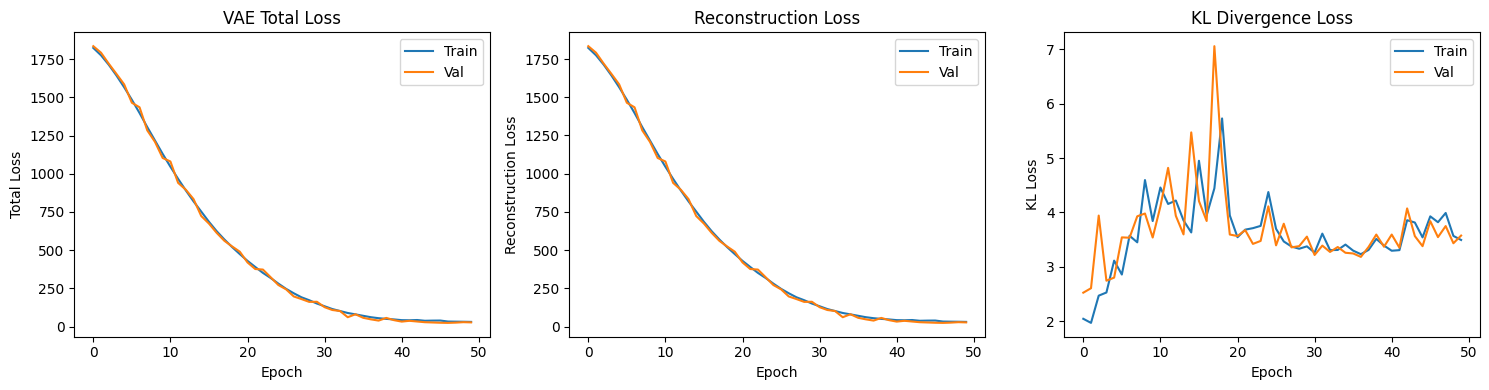

In [9]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('VAE Total Loss')
axes[0].legend()

axes[1].plot(history['train_recon'], label='Train')
axes[1].plot(history['val_recon'], label='Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Reconstruction Loss')
axes[1].set_title('Reconstruction Loss')
axes[1].legend()

axes[2].plot(history['train_kl'], label='Train')
axes[2].plot(history['val_kl'], label='Val')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KL Loss')
axes[2].set_title('KL Divergence Loss')
axes[2].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'vae_training_history.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Anomaly Detection Evaluation


In [10]:
# Load best model
model.load_state_dict(best_model_state)
model.eval()

def compute_reconstruction_errors(model, dataset, device):
    """Compute reconstruction errors for all samples in dataset."""
    errors = []
    labels = []
    
    loader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=0)
    
    with torch.no_grad():
        for data, label in tqdm(loader, desc="Computing errors"):
            data = data.to(device)
            error = model.reconstruction_error(data)
            errors.extend(error.cpu().numpy())
            labels.extend([label] if isinstance(label, int) else label.numpy())
    
    return np.array(errors), np.array(labels)

# Compute errors for normal and anomaly test sets
normal_errors, normal_labels = compute_reconstruction_errors(model, test_normal_dataset, device)
anomaly_errors, anomaly_labels = compute_reconstruction_errors(model, test_anomaly_dataset, device)

print(f"Normal samples: {len(normal_errors)}, mean error: {normal_errors.mean():.4f}")
print(f"Anomaly samples: {len(anomaly_errors)}, mean error: {anomaly_errors.mean():.4f}")



Computing errors:   0%|          | 0/23 [00:00<?, ?it/s]


Computing errors:   4%|▍         | 1/23 [00:00<00:11,  1.85it/s]


Computing errors:   9%|▊         | 2/23 [00:01<00:11,  1.84it/s]


Computing errors:  13%|█▎        | 3/23 [00:01<00:10,  1.88it/s]


Computing errors:  17%|█▋        | 4/23 [00:02<00:09,  1.92it/s]

...


Computing errors:  87%|████████▋ | 20/23 [00:09<00:01,  2.06it/s]


Computing errors:  91%|█████████▏| 21/23 [00:10<00:00,  2.10it/s]


Computing errors:  96%|█████████▌| 22/23 [00:10<00:00,  2.17it/s]


Computing errors: 100%|██████████| 23/23 [00:10<00:00,  2.11it/s]

Normal samples: 713, mean error: 25.3317
Anomaly samples: 709, mean error: 32.7276


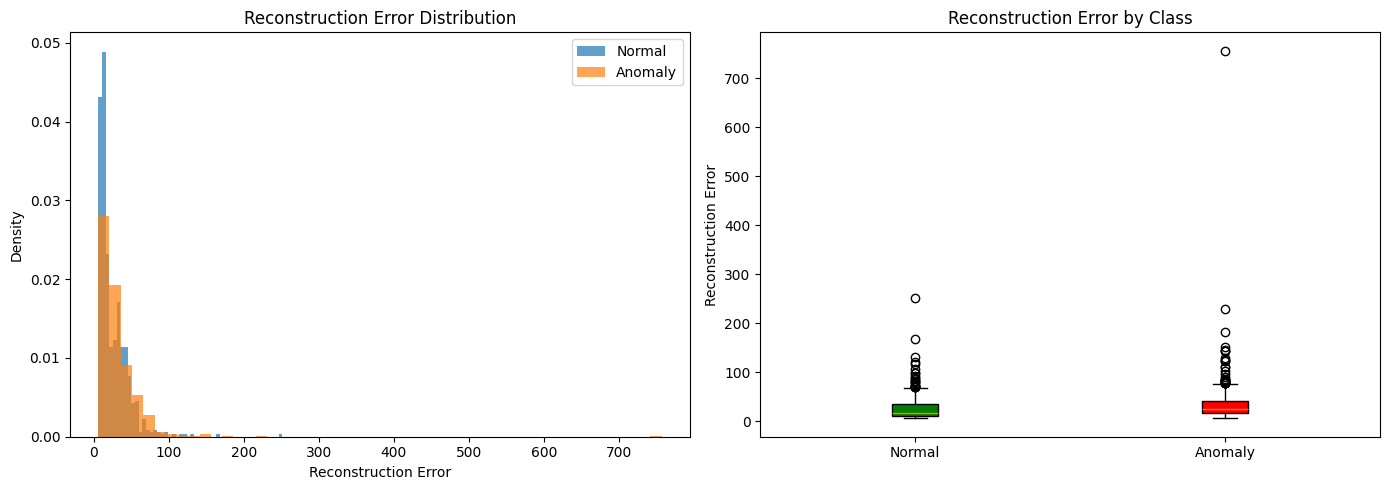

In [11]:
# Visualize reconstruction error distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1 = axes[0]
ax1.hist(normal_errors, bins=50, alpha=0.7, label='Normal', density=True)
ax1.hist(anomaly_errors, bins=50, alpha=0.7, label='Anomaly', density=True)
ax1.set_xlabel('Reconstruction Error')
ax1.set_ylabel('Density')
ax1.set_title('Reconstruction Error Distribution')
ax1.legend()

# Box plot
ax2 = axes[1]
data_to_plot = [normal_errors, anomaly_errors]
bp = ax2.boxplot(data_to_plot, labels=['Normal', 'Anomaly'], patch_artist=True)
bp['boxes'][0].set_facecolor('green')
bp['boxes'][1].set_facecolor('red')
ax2.set_ylabel('Reconstruction Error')
ax2.set_title('Reconstruction Error by Class')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'vae_error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


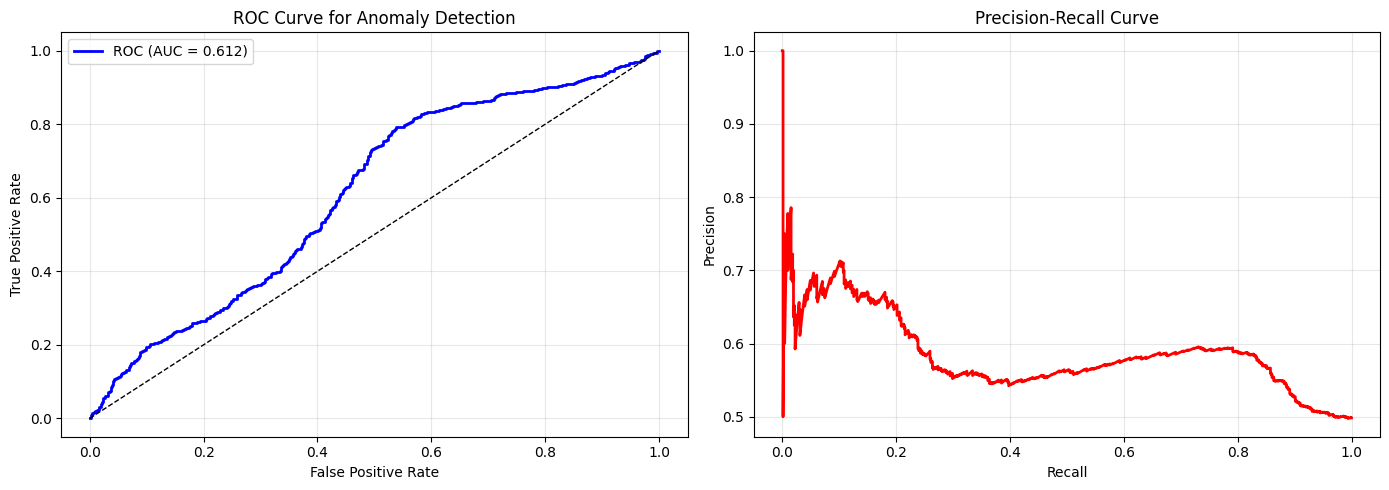

ROC-AUC Score: 0.6117


In [12]:
# ROC Curve and AUC
all_errors = np.concatenate([normal_errors, anomaly_errors])
all_labels = np.concatenate([np.zeros(len(normal_errors)), np.ones(len(anomaly_errors))])

fpr, tpr, thresholds = roc_curve(all_labels, all_errors)
roc_auc = auc(fpr, tpr)

# Precision-Recall curve
precision, recall, pr_thresholds = precision_recall_curve(all_labels, all_errors)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
ax1 = axes[0]
ax1.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve for Anomaly Detection')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Precision-Recall
ax2 = axes[1]
ax2.plot(recall, precision, 'r-', linewidth=2)
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'vae_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")


In [13]:
# Find optimal threshold
# Use validation normal data to set threshold at 95th percentile
val_errors, _ = compute_reconstruction_errors(model, val_dataset, device)
threshold_95 = np.percentile(val_errors, 95)
threshold_99 = np.percentile(val_errors, 99)

print(f"Validation error stats: mean={val_errors.mean():.4f}, std={val_errors.std():.4f}")
print(f"Threshold (95th percentile): {threshold_95:.4f}")
print(f"Threshold (99th percentile): {threshold_99:.4f}")

# Evaluate with different thresholds
def evaluate_threshold(normal_errors, anomaly_errors, threshold):
    normal_pred = (normal_errors > threshold).astype(int)  # 0 for normal, 1 for anomaly
    anomaly_pred = (anomaly_errors > threshold).astype(int)
    
    tn = (normal_pred == 0).sum()  # True negatives
    fp = (normal_pred == 1).sum()  # False positives
    fn = (anomaly_pred == 0).sum()  # False negatives
    tp = (anomaly_pred == 1).sum()  # True positives
    
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1,
            'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp}

print("\nEvaluation with 95th percentile threshold:")
metrics_95 = evaluate_threshold(normal_errors, anomaly_errors, threshold_95)
print(f"  Accuracy: {metrics_95['accuracy']:.4f}")
print(f"  Precision: {metrics_95['precision']:.4f}")
print(f"  Recall: {metrics_95['recall']:.4f}")
print(f"  F1: {metrics_95['f1']:.4f}")

print("\nEvaluation with 99th percentile threshold:")
metrics_99 = evaluate_threshold(normal_errors, anomaly_errors, threshold_99)
print(f"  Accuracy: {metrics_99['accuracy']:.4f}")
print(f"  Precision: {metrics_99['precision']:.4f}")
print(f"  Recall: {metrics_99['recall']:.4f}")
print(f"  F1: {metrics_99['f1']:.4f}")



Computing errors:   0%|          | 0/12 [00:00<?, ?it/s]


Computing errors:   8%|▊         | 1/12 [00:00<00:05,  2.00it/s]


Computing errors:  17%|█▋        | 2/12 [00:01<00:05,  1.97it/s]


Computing errors:  25%|██▌       | 3/12 [00:01<00:04,  1.96it/s]


Computing errors:  33%|███▎      | 4/12 [00:02<00:04,  1.99it/s]

...


Computing errors:  75%|███████▌  | 9/12 [00:04<00:01,  2.01it/s]


Computing errors:  83%|████████▎ | 10/12 [00:05<00:00,  2.00it/s]


Computing errors:  92%|█████████▏| 11/12 [00:05<00:00,  2.01it/s]


Computing errors: 100%|██████████| 12/12 [00:05<00:00,  2.16it/s]

Validation error stats: mean=25.6748, std=20.8753
Threshold (95th percentile): 59.0176
Threshold (99th percentile): 123.0476

Evaluation with 95th percentile threshold:
  Accuracy: 0.5309
  Precision: 0.6875
  Recall: 0.1086
  F1: 0.1876

Evaluation with 99th percentile threshold:
  Accuracy: 0.5070
  Precision: 0.7857
  Recall: 0.0155
  F1: 0.0304


## 5. Save Model


In [14]:
# Save model
model_path = MODEL_DIR / 'beehive_vae_anomaly.pth'
torch.save({
    'model_state_dict': best_model_state,
    'input_channels': input_channels,
    'seq_length': seq_length,
    'latent_dim': 16,
    'config': config_dict,
    'threshold_95': float(threshold_95),
    'threshold_99': float(threshold_99),
    'val_error_mean': float(val_errors.mean()),
    'val_error_std': float(val_errors.std()),
    'roc_auc': float(roc_auc),
    'history': history
}, model_path)

print(f"Model saved to {model_path}")

# Save history
history_df = pd.DataFrame(history)
history_df.to_csv(MODEL_DIR / 'vae_training_history.csv', index=False)


Model saved to ../outputs/models/beehive_vae_anomaly.pth


In [15]:
print("=" * 60)
print("VAE ANOMALY DETECTOR SUMMARY")
print("=" * 60)
print(f"\nModel Architecture: ConvVAE")
print(f"  - Input: MFCC with deltas ({input_channels} channels)")
print(f"  - Latent dimension: 16")
print(f"  - Total parameters: {sum(p.numel() for p in model.parameters()):,}")

print(f"\nTraining:")
print(f"  - Trained on normal (queenright) samples only")
print(f"  - Training samples: {len(train_normal_df)}")
print(f"  - Epochs trained: {len(history['train_loss'])}")
print(f"  - Best validation loss: {best_val_loss:.4f}")

print(f"\nAnomaly Detection Performance:")
print(f"  - ROC-AUC: {roc_auc:.4f}")
print(f"  - Threshold (95th pct): {threshold_95:.4f}")
print(f"  - F1 @ 95th pct: {metrics_95['f1']:.4f}")

print(f"\nSaved files:")
print(f"  - {model_path}")
print(f"  - {MODEL_DIR / 'vae_training_history.csv'}")


VAE ANOMALY DETECTOR SUMMARY

Model Architecture: ConvVAE
  - Input: MFCC with deltas (39 channels)
  - Latent dimension: 16
  - Total parameters: 441,991

Training:
  - Trained on normal (queenright) samples only
  - Training samples: 2493
  - Epochs trained: 50
  - Best validation loss: 24.7373

Anomaly Detection Performance:
  - ROC-AUC: 0.6117
  - Threshold (95th pct): 59.0176
  - F1 @ 95th pct: 0.1876

Saved files:
  - ../outputs/models/beehive_vae_anomaly.pth
  - ../outputs/models/vae_training_history.csv
